In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [2]:
# Define categorical data types to reduce memory usage
dtype_dict = {
    "CRIME": "category",
    "VICT SEX": "category",
    "VICT DESCENT": "category",
    "PLACE": "category",
    "WEAPON CATEGORY": "category",
}

# Load merged crime, weather and districts dataset with optimized memory settings
merged_data = pd.read_csv(
    "../processed_data/merged_weather_crime_districts_data.csv",
    dtype=dtype_dict,
    parse_dates=["DATE RPTD", "DATETIME OCC"],
    low_memory=False
)

# Load crimes with categories dataset
crime_with_categories = pd.read_csv(
    "../processed_data/cleaned_crime_data_with_categories.csv",
    dtype=dtype_dict,
    parse_dates=["DATE RPTD", "DATETIME OCC"],
    low_memory=False
)

merged_data.head()

,ID,DATE RPTD,CRIME,VICT AGE,VICT SEX,VICT DESCENT,PLACE,LAT,LON,DATETIME OCC,WEAPON CATEGORY,TEMPERATURE,PERCIPITATION,WIND SPEED,RAIN,SNOWFALL,DISTRICT
0,1307355,2010-02-20,VIOLATION OF COURT ORDER,48,M,H,SINGLE FAMILY DWELLING,33.9825,-118.2695,2010-02-20 13:00:00,No Weapon,14.2,0.0,9.7,0.0,0.0,9
1,11401303,2010-09-13,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",Unknown,M,W,STREET,33.9599,-118.3962,2010-09-12 00:00:00,No Weapon,16.5,0.0,4.1,0.0,0.0,11
2,70309629,2010-08-09,OTHER MISCELLANEOUS CRIME,Unknown,M,H,ALLEY,34.0224,-118.2524,2010-08-09 15:00:00,No Weapon,25.5,0.0,11.5,0.0,0.0,9
3,90631215,2010-01-05,VIOLATION OF COURT ORDER,47,F,W,STREET,34.1016,-118.3295,2010-01-05 01:00:00,Firearm,8.1,0.0,7.4,0.0,0.0,13
4,100100501,2010-01-03,"RAPE, ATTEMPTED",47,F,H,ALLEY,34.0387,-118.2488,2010-01-02 21:00:00,Strong-Arm,11.6,0.0,8.5,0.0,0.0,14


In [3]:
merged_data.shape

(2119451, 17)

In [4]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2119451 entries, 0 to 2119450
Data columns (total 17 columns):
 #   Column           Dtype         
---  ------           -----         
 0   ID               int64         
 1   DATE RPTD        datetime64[ns]
 2   CRIME            category      
 3   VICT AGE         object        
 4   VICT SEX         category      
 5   VICT DESCENT     category      
 6   PLACE            category      
 7   LAT              float64       
 8   LON              float64       
 9   DATETIME OCC     datetime64[ns]
 10  WEAPON CATEGORY  category      
 11  TEMPERATURE      float64       
 12  PERCIPITATION    float64       
 13  WIND SPEED       float64       
 14  RAIN             float64       
 15  SNOWFALL         float64       
 16  DISTRICT         int64         
dtypes: category(5), datetime64[ns](2), float64(7), int64(2), object(1)
memory usage: 208.2+ MB


In [5]:
data = merged_data.copy()
data.head()

,ID,DATE RPTD,CRIME,VICT AGE,VICT SEX,VICT DESCENT,PLACE,LAT,LON,DATETIME OCC,WEAPON CATEGORY,TEMPERATURE,PERCIPITATION,WIND SPEED,RAIN,SNOWFALL,DISTRICT
0,1307355,2010-02-20,VIOLATION OF COURT ORDER,48,M,H,SINGLE FAMILY DWELLING,33.9825,-118.2695,2010-02-20 13:00:00,No Weapon,14.2,0.0,9.7,0.0,0.0,9
1,11401303,2010-09-13,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",Unknown,M,W,STREET,33.9599,-118.3962,2010-09-12 00:00:00,No Weapon,16.5,0.0,4.1,0.0,0.0,11
2,70309629,2010-08-09,OTHER MISCELLANEOUS CRIME,Unknown,M,H,ALLEY,34.0224,-118.2524,2010-08-09 15:00:00,No Weapon,25.5,0.0,11.5,0.0,0.0,9
3,90631215,2010-01-05,VIOLATION OF COURT ORDER,47,F,W,STREET,34.1016,-118.3295,2010-01-05 01:00:00,Firearm,8.1,0.0,7.4,0.0,0.0,13
4,100100501,2010-01-03,"RAPE, ATTEMPTED",47,F,H,ALLEY,34.0387,-118.2488,2010-01-02 21:00:00,Strong-Arm,11.6,0.0,8.5,0.0,0.0,14


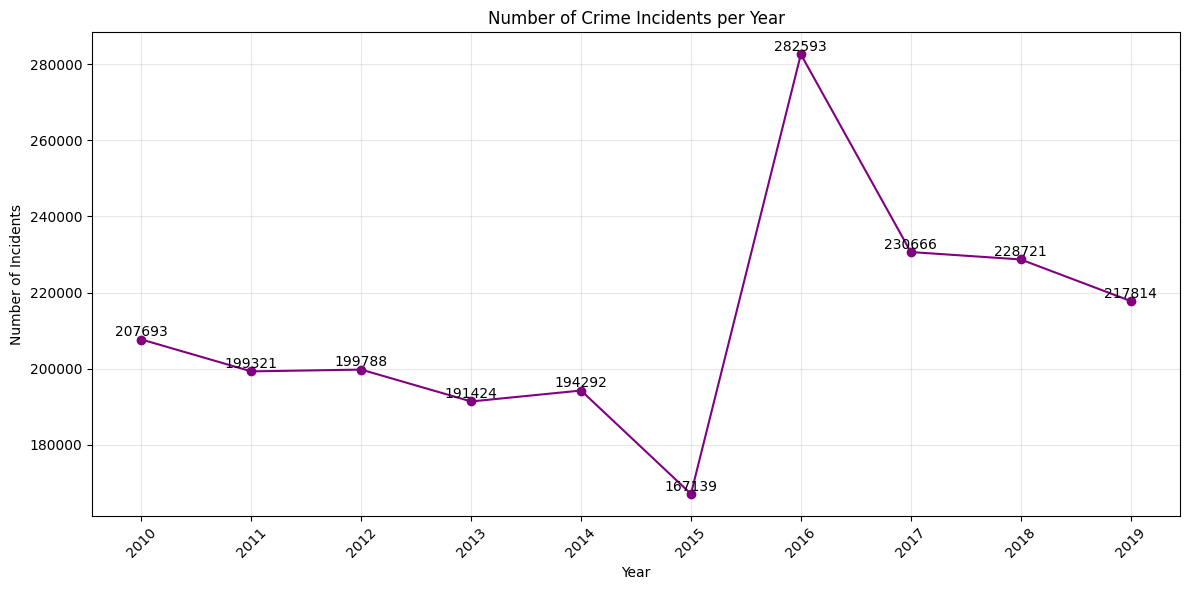

In [6]:
# Extract year
data['YEAR'] = data['DATETIME OCC'].dt.year

# Count incidents per year
crime_per_year = data['YEAR'].value_counts().sort_index()

# Drop year column
data.drop(columns=["YEAR"], inplace=True)

# Plot line chart with markers
plt.figure(figsize=(12,6))
plt.plot(crime_per_year.index, crime_per_year.values, marker='o', linestyle='-', color='purple')

# Add numbers on top of points
for i, count in enumerate(crime_per_year.values):
    plt.text(crime_per_year.index[i], count + 50, str(count), ha='center', va='bottom', fontsize=10)

plt.title("Number of Crime Incidents per Year")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.xticks(crime_per_year.index, rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

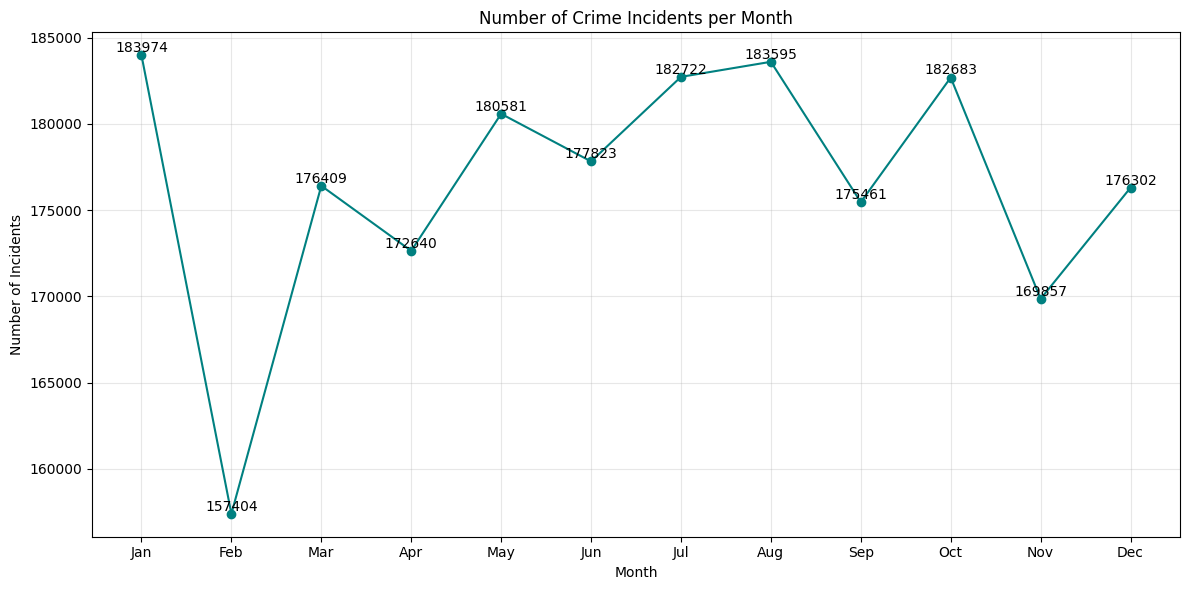

In [7]:
# Extract month
data['MONTH'] = data['DATETIME OCC'].dt.month

# Count incidents per month
crime_per_month = data['MONTH'].value_counts().sort_index()

# Drop month column
data.drop(columns=["MONTH"], inplace=True)

# Month names
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Plot line chart
plt.figure(figsize=(12,6))
plt.plot(months, crime_per_month.values, marker='o', linestyle='-', color='teal')

# Add numbers on each point
for i, count in enumerate(crime_per_month.values):
    plt.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=10)

plt.title("Number of Crime Incidents per Month")
plt.xlabel("Month")
plt.ylabel("Number of Incidents")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

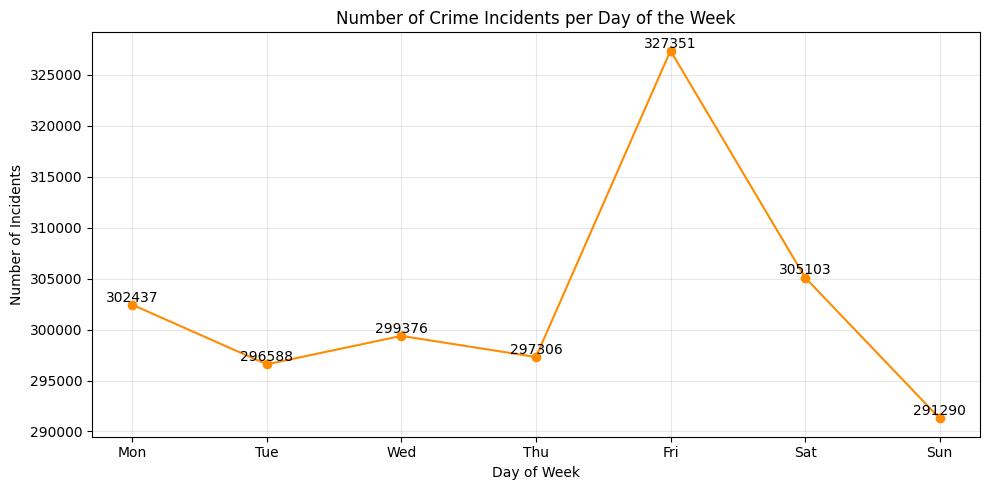

In [8]:
# Extract day of week (0=Monday, 6=Sunday)
data['WEEKDAY'] = data['DATETIME OCC'].dt.dayofweek

# Count incidents per weekday
crime_per_weekday = data['WEEKDAY'].value_counts().sort_index()

# Drop weekday column
data.drop(columns=["WEEKDAY"], inplace=True)

# Weekday names
weekdays = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# Plot line chart with markers
plt.figure(figsize=(10,5))
plt.plot(weekdays, crime_per_weekday.values, marker='o', linestyle='-', color='darkorange')

# Add numbers on each point
for i, count in enumerate(crime_per_weekday.values):
    plt.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=10)

plt.title("Number of Crime Incidents per Day of the Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Incidents")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


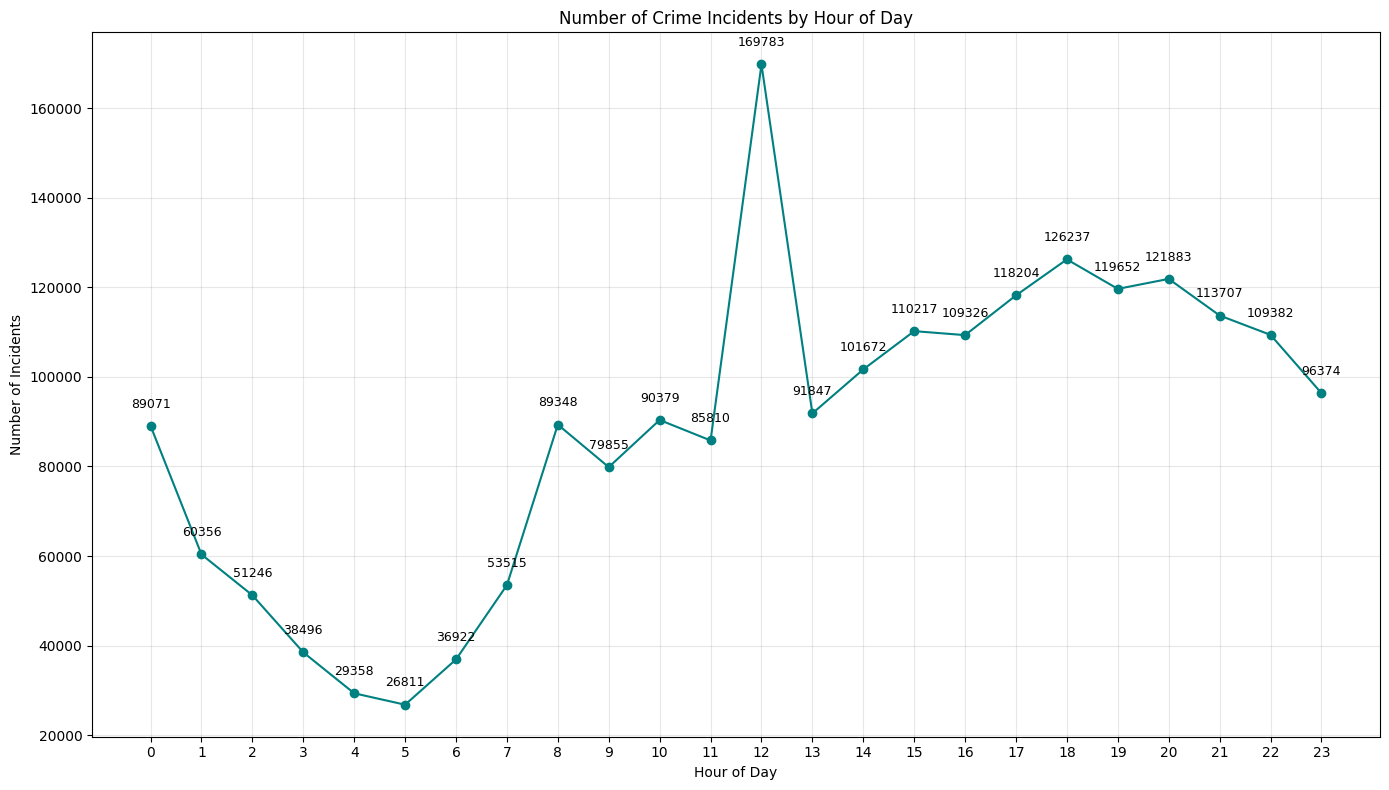

In [9]:
# Convert 'TIME OCC' to hour
data['HOUR'] = data['DATETIME OCC'].dt.hour

# Count incidents per hour
crime_per_hour = data['HOUR'].value_counts().sort_index()

# Drop hour column
data.drop(columns=["HOUR"], inplace=True)

# Plot line chart with markers
plt.figure(figsize=(14,8))
plt.plot(crime_per_hour.index, crime_per_hour.values, marker='o', linestyle='-', color='teal')

# Add numbers above points, slightly offset to avoid overlap
for i, count in enumerate(crime_per_hour.values):
    plt.text(crime_per_hour.index[i], count + max(crime_per_hour.values)*0.02, str(count),
             ha='center', va='bottom', fontsize=9)

plt.title("Number of Crime Incidents by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Incidents")
plt.xticks(range(0,24))  # Show all hours
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

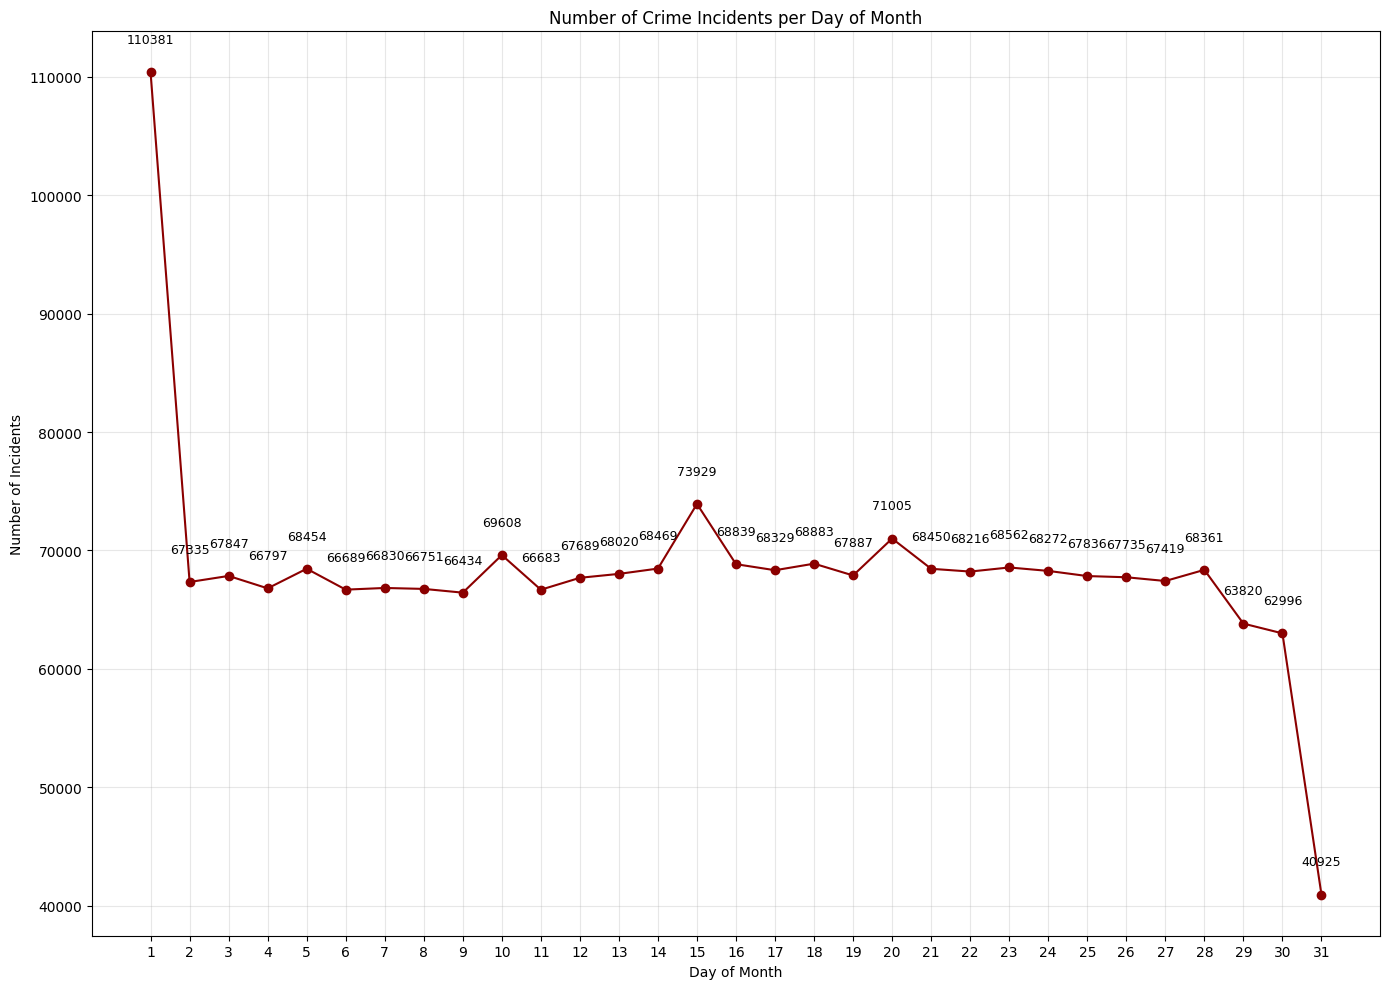

In [10]:
# Extract day of month
data['DAY'] = data['DATETIME OCC'].dt.day

# Count incidents per day of month
crime_per_day = data['DAY'].value_counts().sort_index()

# Drop day column
data.drop(columns=["DAY"], inplace=True)

# Plot line chart with markers
plt.figure(figsize=(14,10))
plt.plot(crime_per_day.index, crime_per_day.values, marker='o', linestyle='-', color='darkred')

# Add numbers above points
for i, count in enumerate(crime_per_day.values):
    plt.text(crime_per_day.index[i], count + max(crime_per_day.values)*0.02, str(count),
             ha='center', va='bottom', fontsize=9)

plt.title("Number of Crime Incidents per Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Number of Incidents")
plt.xticks(range(1,32))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

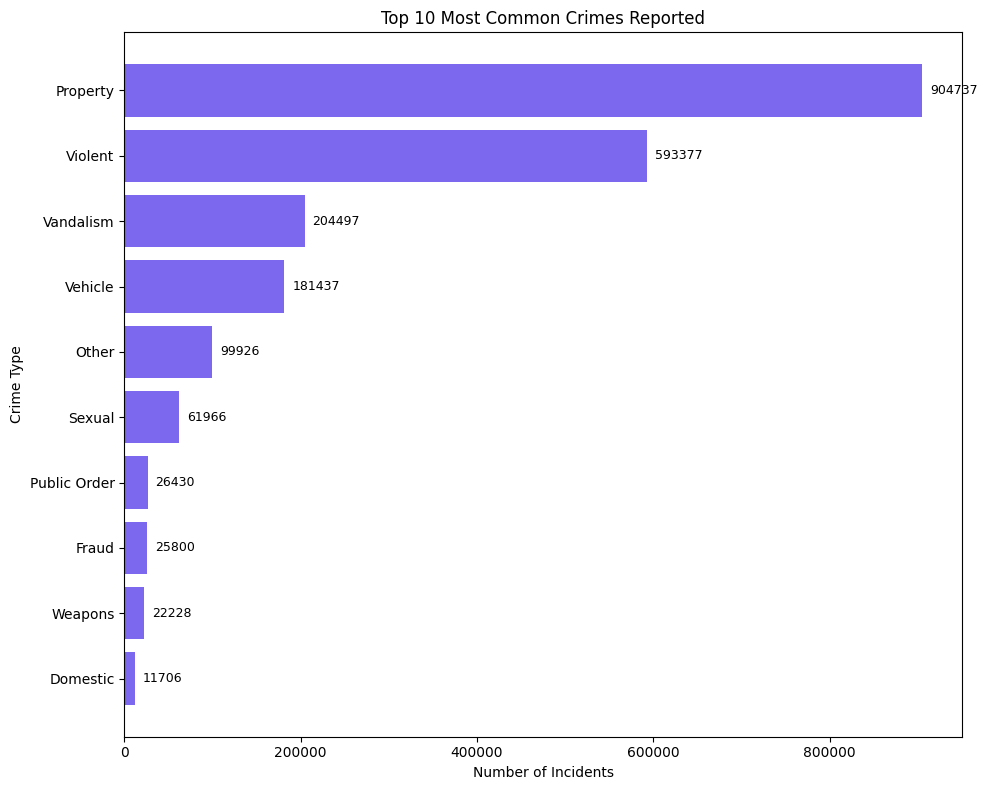

In [3]:
# Count incidents per crime type
crime_counts = crime_with_categories['crime_category'].value_counts()

# Take top 10 most common crimes
top10_crimes = crime_counts.head(10)

# Plot bar chart
plt.figure(figsize=(10,8))
bars = plt.barh(top10_crimes.index[::-1], top10_crimes.values[::-1], color='mediumslateblue')

# Add numbers on bars
for i, count in enumerate(top10_crimes.values[::-1]):
    plt.text(count + max(top10_crimes.values)*0.01, i, str(count),
             va='center', fontsize=9)

plt.title("Top 10 Most Common Crimes Reported")
plt.xlabel("Number of Incidents")
plt.ylabel("Crime Type")
plt.tight_layout()
plt.show()

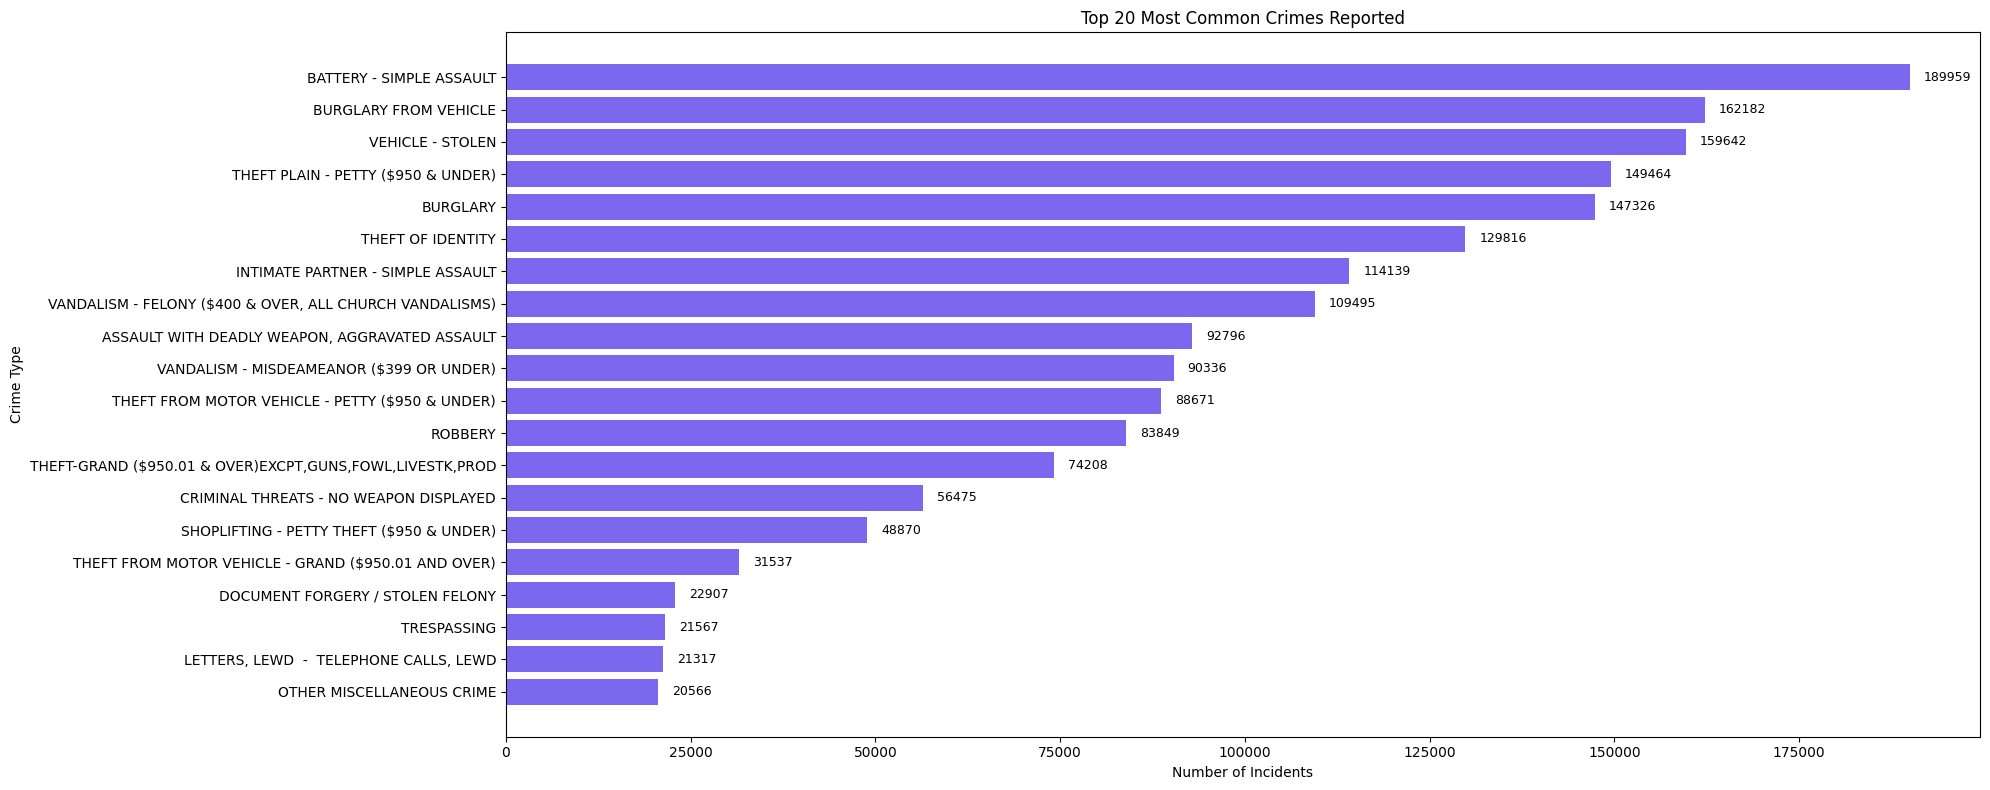

In [ ]:
# Count incidents per crime type
crime_counts = data['CRIME'].value_counts()

# Take top 20 most common crimes
top20_crimes = crime_counts.head(20)

# Plot bar chart
plt.figure(figsize=(20,8))
bars = plt.barh(top20_crimes.index[::-1], top20_crimes.values[::-1], color='mediumslateblue')

# Add numbers on bars
for i, count in enumerate(top20_crimes.values[::-1]):
    plt.text(count + max(top20_crimes.values)*0.01, i, str(count),
             va='center', fontsize=9)

plt.title("Top 20 Most Common Crimes Reported")
plt.xlabel("Number of Incidents")
plt.ylabel("Crime Type")
plt.tight_layout()
plt.show()

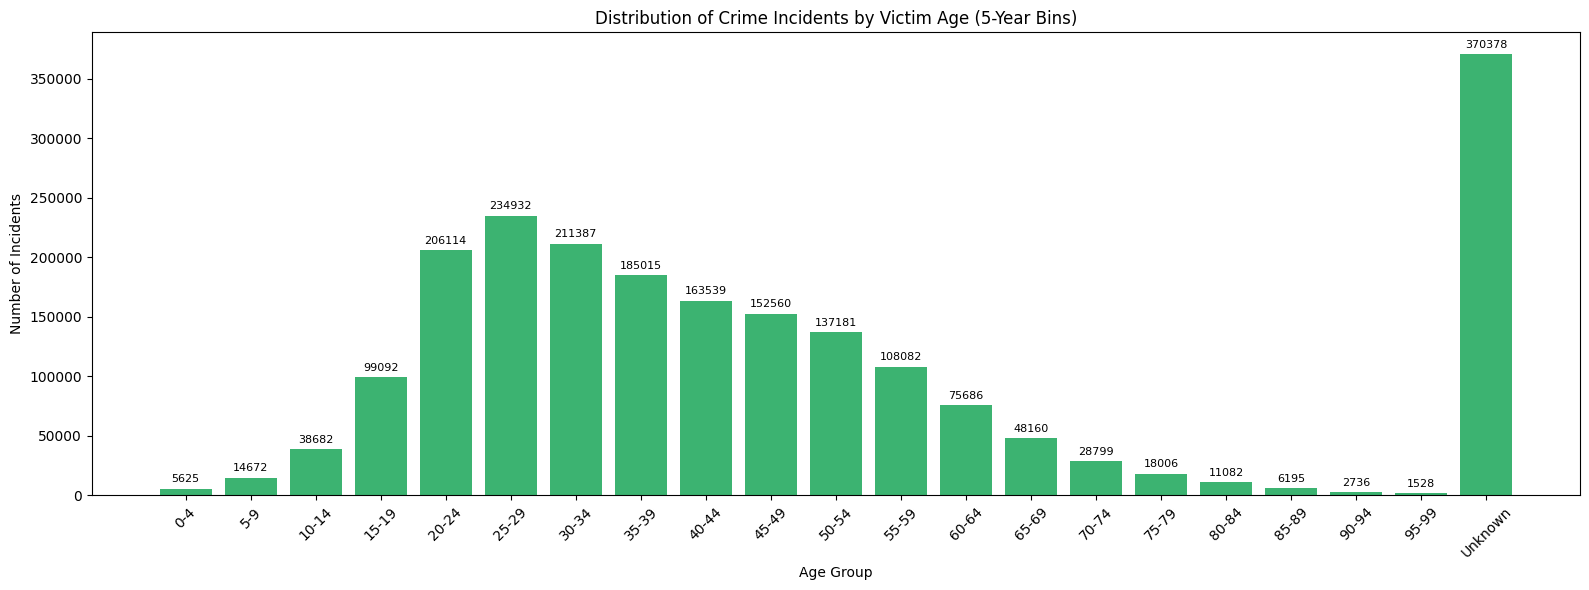

In [12]:
# Create 5-year age bins
def age_group_5yr(age):
    try:
        age = int(age)
        lower = (age // 5) * 5
        upper = lower + 4
        return f"{lower}-{upper}"
    except:
        return "Unknown"

data['AGE GROUP'] = data['VICT AGE'].apply(age_group_5yr)

# Count incidents per age group
age_counts = data['AGE GROUP'].value_counts()

# Drop age group column
data.drop(columns=["AGE GROUP"], inplace=True)

# Sort age groups numerically, Unknown at the end
age_bins = [age for age in age_counts.index if age != "Unknown"]
age_bins_sorted = sorted(age_bins, key=lambda x: int(x.split("-")[0]))
if "Unknown" in age_counts.index:
    age_bins_sorted.append("Unknown")

age_counts = age_counts[age_bins_sorted]

# Plot bar chart
plt.figure(figsize=(16,6))
bars = plt.bar(age_counts.index, age_counts.values, color='mediumseagreen')

# Add numbers on top of bars
for i, count in enumerate(age_counts.values):
    plt.text(i, count + max(age_counts.values)*0.01, str(count),
             ha='center', va='bottom', fontsize=8)

plt.title("Distribution of Crime Incidents by Victim Age (5-Year Bins)")
plt.xlabel("Age Group")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

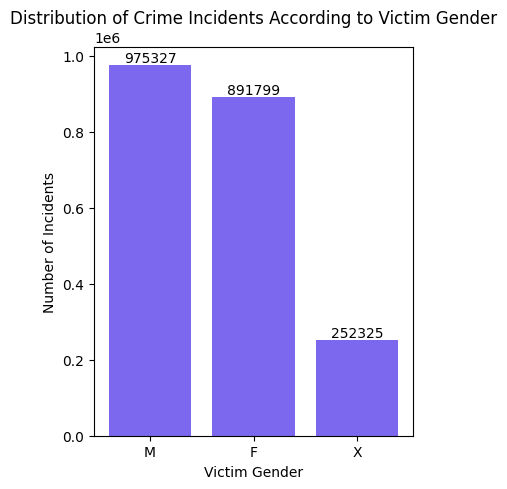

In [13]:
# Count incidents by victim sex
crime_by_gender = data['VICT SEX'].value_counts()

# Plot bar chart
plt.figure(figsize=(4,5))
bars = plt.bar(crime_by_gender.index, crime_by_gender.values, color='mediumslateblue')

# Add numbers on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, str(int(height)),
             ha='center', va='bottom', fontsize=10)

plt.title("Distribution of Crime Incidents According to Victim Gender")
plt.xlabel("Victim Gender")
plt.ylabel("Number of Incidents")
plt.tight_layout()
plt.show()

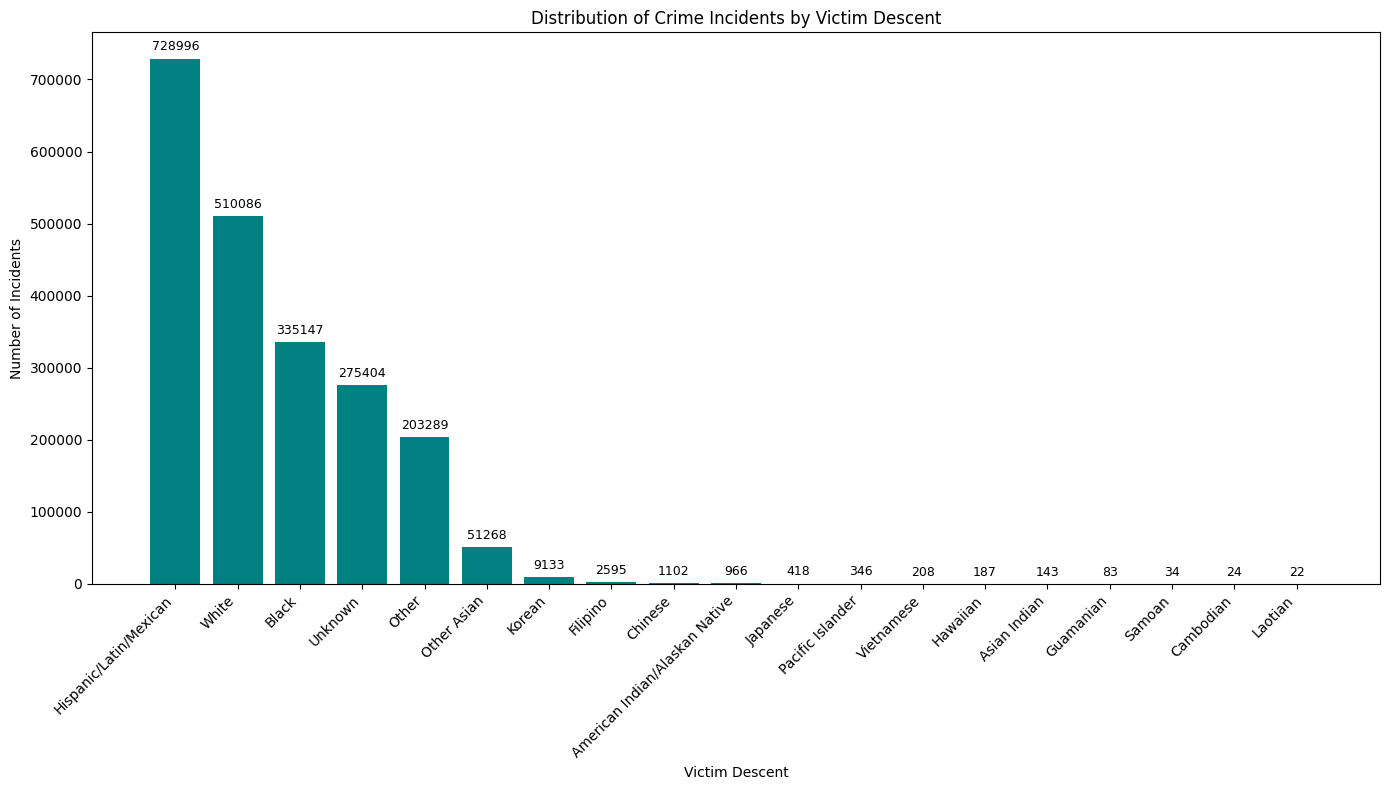

In [14]:
# Map codes to full names
descent_map = {
    "A": "Other Asian",
    "B": "Black",
    "C": "Chinese",
    "D": "Cambodian",
    "F": "Filipino",
    "G": "Guamanian",
    "H": "Hispanic/Latin/Mexican",
    "I": "American Indian/Alaskan Native",
    "J": "Japanese",
    "K": "Korean",
    "L": "Laotian",
    "O": "Other",
    "P": "Pacific Islander",
    "S": "Samoan",
    "U": "Hawaiian",
    "V": "Vietnamese",
    "W": "White",
    "X": "Unknown",
    "Z": "Asian Indian"
}

data['DESCENT NAME'] = data['VICT DESCENT'].map(descent_map)

# Count incidents per descent
descent_counts = data['DESCENT NAME'].value_counts()

# Drop descent column
data.drop(columns=["DESCENT NAME"], inplace=True)

# Plot bar chart
plt.figure(figsize=(14,8))
bars = plt.bar(descent_counts.index, descent_counts.values, color='teal')

# Add numbers on top of bars
for i, count in enumerate(descent_counts.values):
    plt.text(i, count + max(descent_counts.values)*0.01, str(count),
             ha='center', va='bottom', fontsize=9)

plt.title("Distribution of Crime Incidents by Victim Descent")
plt.xlabel("Victim Descent")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

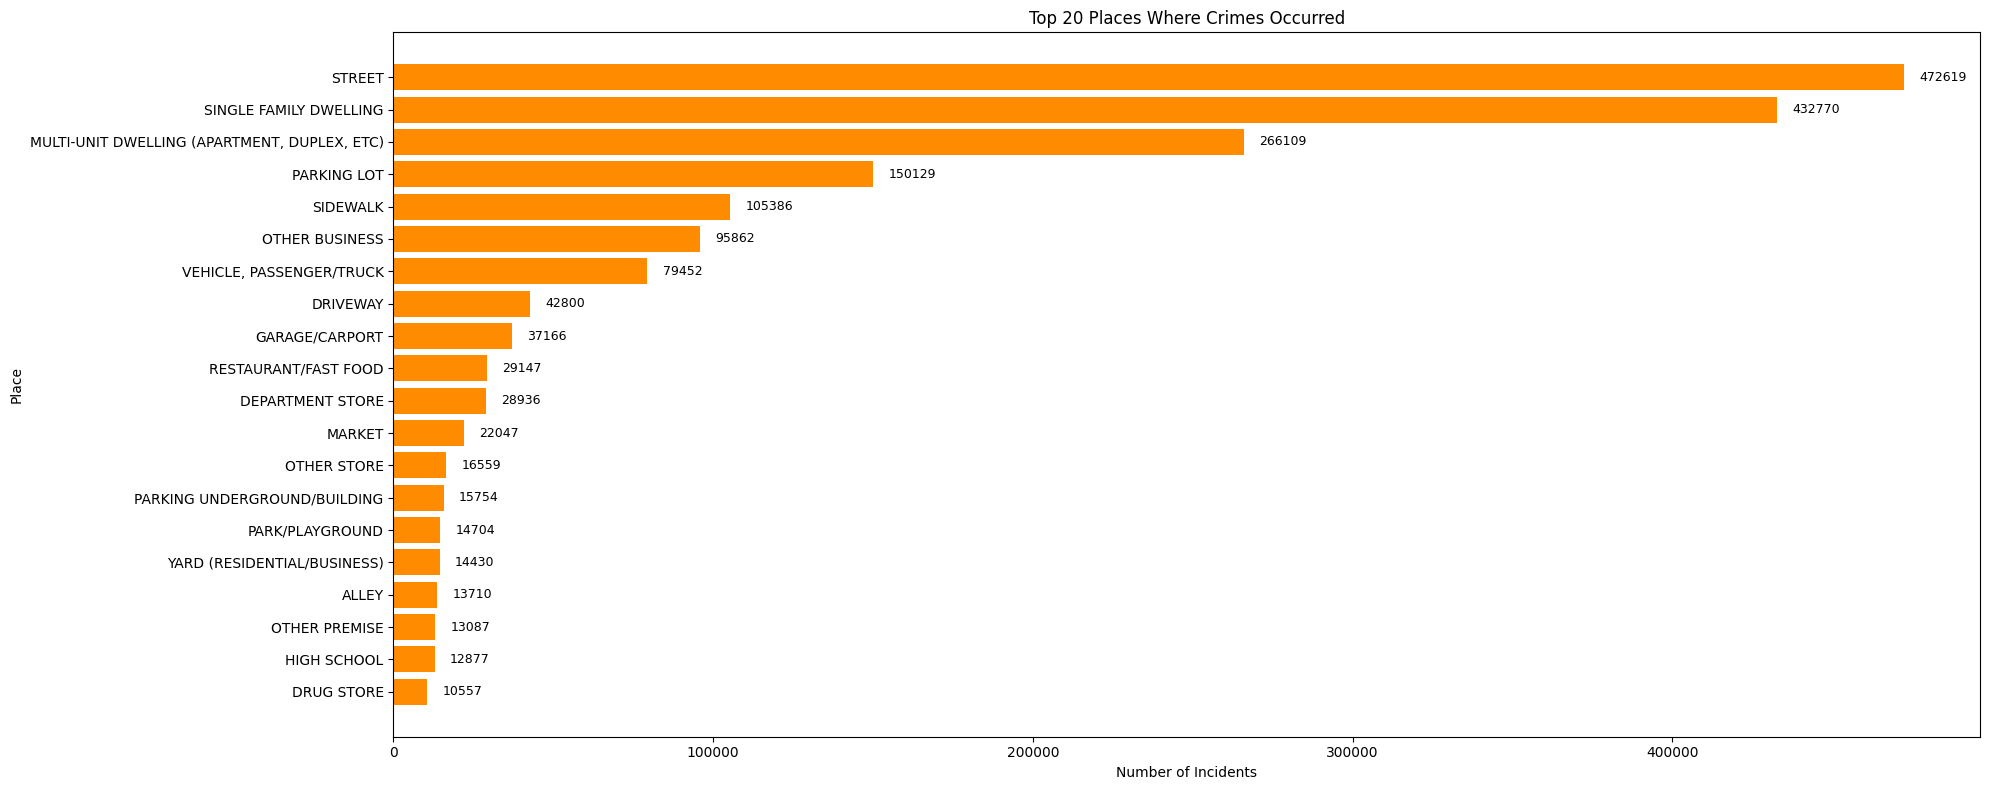

In [15]:
# Count incidents per place
place_counts = data['PLACE'].value_counts()

# Take top 20 most common places
top20_places = place_counts.head(20)

# Plot horizontal bar chart
plt.figure(figsize=(20,8))
bars = plt.barh(top20_places.index[::-1], top20_places.values[::-1], color='darkorange')

# Add numbers on bars
for i, count in enumerate(top20_places.values[::-1]):
    plt.text(count + max(top20_places.values)*0.01, i, str(count),
             va='center', fontsize=9)

plt.title("Top 20 Places Where Crimes Occurred")
plt.xlabel("Number of Incidents")
plt.ylabel("Place")
plt.tight_layout()
plt.show()

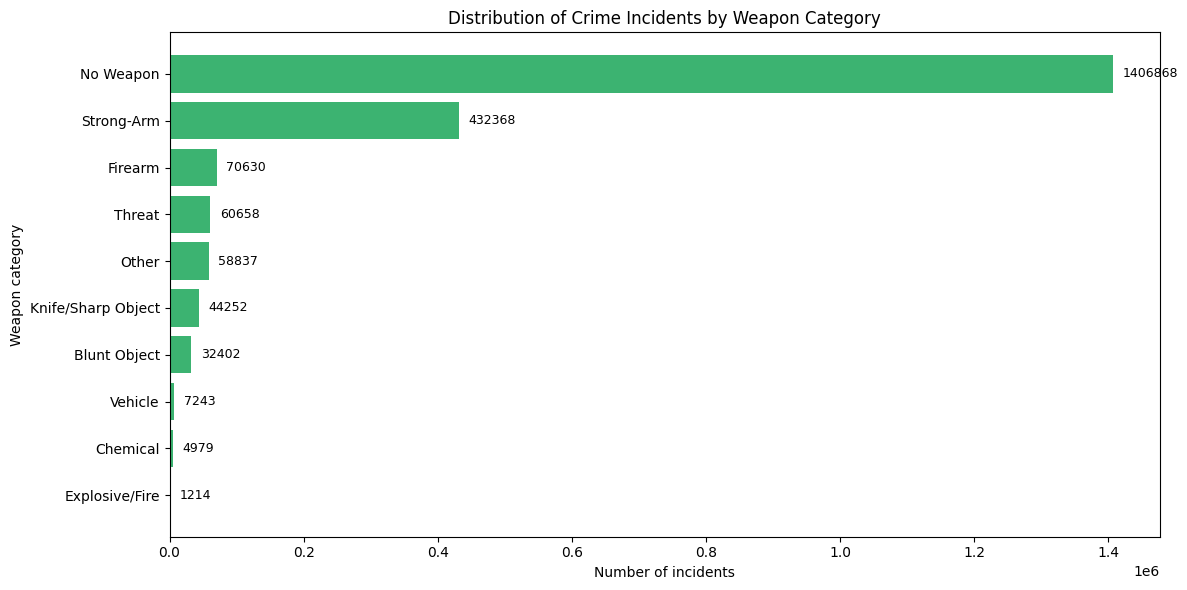

In [16]:
# Count incidents per weapon category
weapon_counts = data['WEAPON CATEGORY'].value_counts()

# Plot horizontal bar chart for all weapon categories
plt.figure(figsize=(12,6))
bars = plt.barh(weapon_counts.index[::-1], weapon_counts.values[::-1], color='mediumseagreen')

# Add numbers on bars
for i, count in enumerate(weapon_counts.values[::-1]):
    plt.text(count + max(weapon_counts.values)*0.01, i, str(count),
             va='center', fontsize=9)

plt.title("Distribution of Crime Incidents by Weapon Category")
plt.xlabel("Number of incidents")
plt.ylabel("Weapon category")
plt.tight_layout()
plt.show()

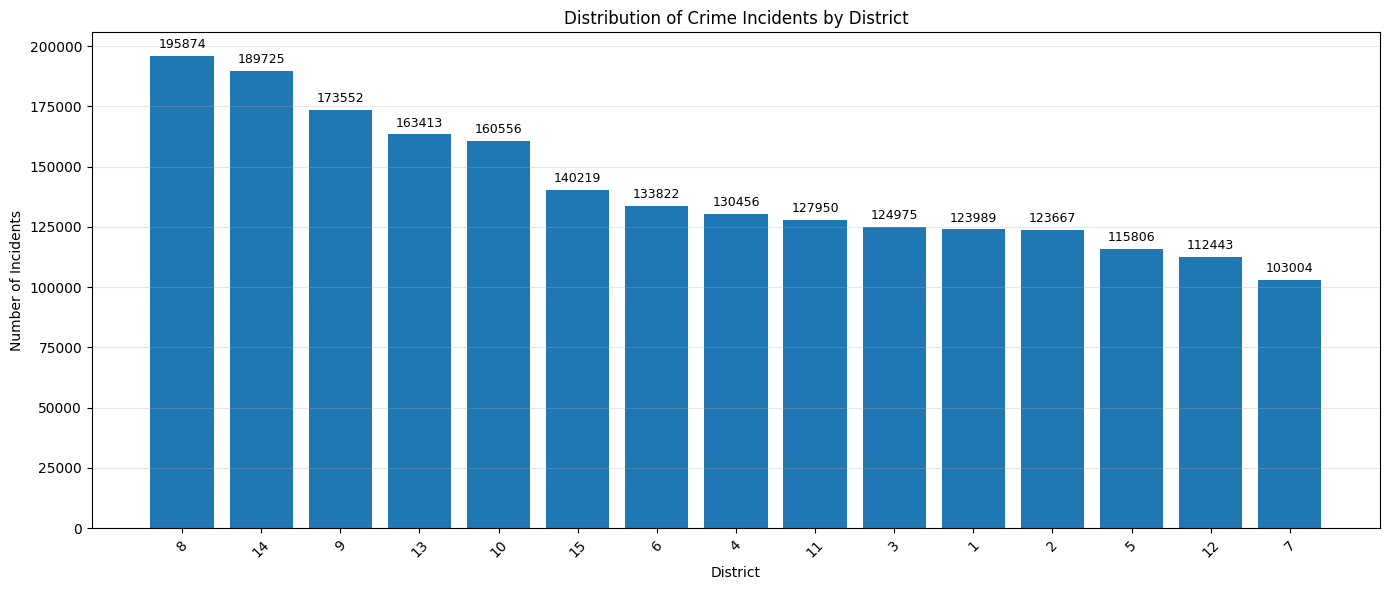

In [17]:
# Count incidents per district
district_counts = (
    data['DISTRICT']
    .value_counts()
    .sort_values(ascending=False)   # sort by number of incidents
)

# Plot candle (bar) chart
plt.figure(figsize=(14,6))
bars = plt.bar(
    district_counts.index.astype(str),
    district_counts.values
)

# Add numbers above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + max(district_counts.values)*0.01,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Distribution of Crime Incidents by District")
plt.xlabel("District")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

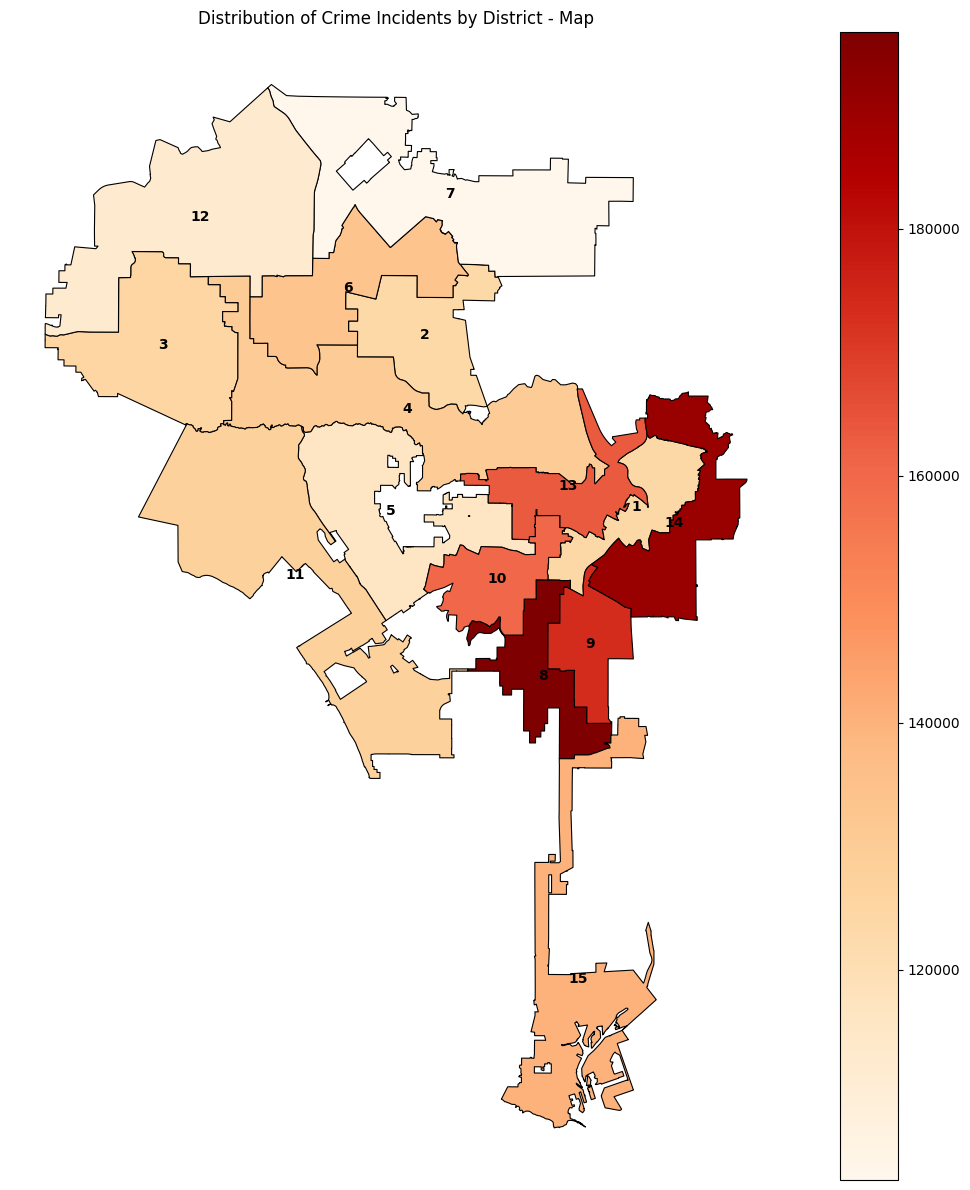

In [18]:
# Count incidents per district
district_counts = data['DISTRICT'].value_counts().sort_index()
district_counts = district_counts.rename_axis('DISTRICT').reset_index(name='CRIME_COUNT')

# Load LA City Council districts shapefile
districts_path = "../raw_data/LA_City_Council_Districts/LA_City_Council_Districts.shp"
districts_gdf = gpd.read_file(districts_path)

# Merge crime counts for coloring
districts_gdf = districts_gdf.merge(district_counts, on='DISTRICT', how='left')
districts_gdf['CRIME_COUNT'] = districts_gdf['CRIME_COUNT']

# Plot choropleth
fig, ax = plt.subplots(figsize=(12,12))
districts_gdf.plot(column='CRIME_COUNT', cmap='OrRd', linewidth=0.8, edgecolor='black', legend=True, ax=ax)

# Overlay district numbers
for idx, row in districts_gdf.iterrows():
    plt.text(row['geometry'].centroid.x, row['geometry'].centroid.y,
             str(int(row['DISTRICT'])), ha='center', va='center', fontsize=10, fontweight='bold', color='black')

plt.title("Distribution of Crime Incidents by District - Map")
plt.axis('off')
plt.tight_layout()
plt.show()

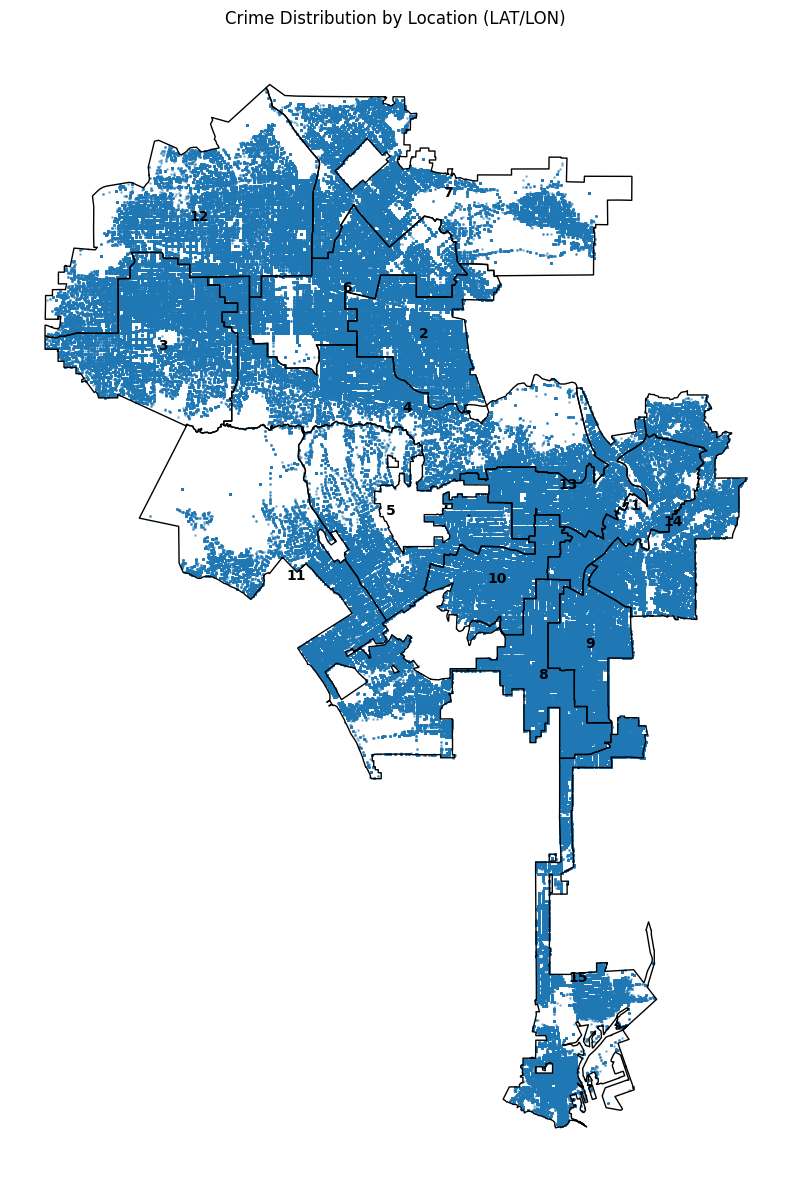

In [19]:
# Convert crime dataframe → GeoDataFrame
crime_gdf = gpd.GeoDataFrame(
    data,
    geometry=gpd.points_from_xy(data["LON"], data["LAT"]),
    crs="EPSG:4326"
)

# Load LA City Council districts shapefile
districts_path = "../raw_data/LA_City_Council_Districts/LA_City_Council_Districts.shp"
districts_gdf = gpd.read_file(districts_path)

# Ensure same CRS
districts_gdf = districts_gdf.to_crs(crime_gdf.crs)

fig, ax = plt.subplots(figsize=(12,12))

# Plot crime points
crime_gdf.plot(
    ax=ax,
    markersize=1,
    alpha=0.4
)

# Plot districts
districts_gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1
)

# Add district labels
for _, row in districts_gdf.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x,
        centroid.y,
        str(int(row["DISTRICT"])),
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Crime Distribution by Location (LAT/LON)")
plt.axis("off")
plt.tight_layout()
plt.show()

In [20]:
# # ------------------- CHECK AGAIN - Identify the columns suitable for heatmap analysis ---------------------------

# import folium
# from folium.plugins import HeatMap

# # Load districts
# districts_path = "../raw_data/LA_City_Council_Districts/LA_City_Council_Districts.shp"
# districts_gdf = gpd.read_file(districts_path)
# districts_gdf = districts_gdf.to_crs("EPSG:4326")

# # Extract year
# data["YEAR"] = pd.to_datetime(data["DATETIME OCC"]).dt.year

# # Create map first
# m = folium.Map(
#     location=[34.05, -118.25],
#     zoom_start=10,
#     tiles="cartodbpositron"
# )

# # Add district borders
# folium.GeoJson(
#     districts_gdf,
#     name="District Borders",
#     style_function=lambda feature: {
#         "fillColor": "none",
#         "color": "black",
#         "weight": 2
#     }
# ).add_to(m)

# # Add heatmaps per year
# for year in sorted(data["YEAR"].dropna().unique()):

#     subset = data[data["YEAR"] == year]
#     heat_data = subset[["LAT", "LON"]].dropna().values.tolist()

#     fg = folium.FeatureGroup(name=str(year))

#     HeatMap(
#         heat_data,
#         radius=8,
#         blur=12,
#         min_opacity=0.3
#     ).add_to(fg)

#     fg.add_to(m)

# # Drop year column
# data.drop(columns=["YEAR"], inplace=True)

# # Add district labels
# for _, row in districts_gdf.iterrows():
#     centroid = row.geometry.centroid
#     folium.Marker(
#         location=[centroid.y, centroid.x],
#         icon=folium.DivIcon(
#             html=f"""<div style="font-size:10pt;font-weight:bold;color:black;">{int(row['DISTRICT'])}</div>"""
#         )
#     ).add_to(m)

# # Add layer control
# folium.LayerControl(collapsed=False).add_to(m)

# # Show map
# m

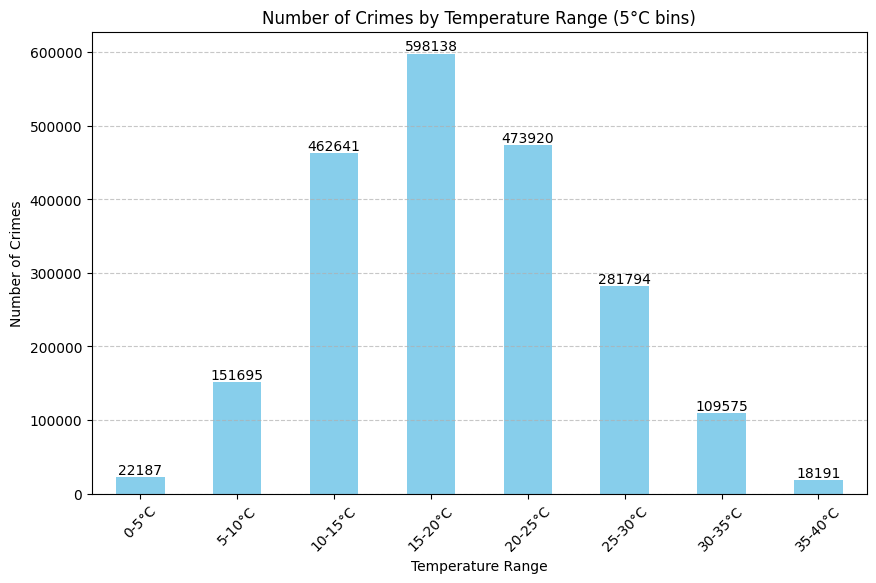

In [21]:
# Define 5°C bins
bins = list(range(0, 45, 5))  # 0, 5, 10, 15, 20, ..., 40
labels = [f'{i}-{i+5}°C' for i in bins[:-1]]

# Create a new column for temperature range
data['TEMP RANGE'] = pd.cut(data['TEMPERATURE'], bins=bins, labels=labels, include_lowest=True)

# Count crimes in each temperature range
temp_counts = data['TEMP RANGE'].value_counts().sort_index()

# Drop descent column
data.drop(columns=["TEMP RANGE"], inplace=True)

# Plot
plt.figure(figsize=(10,6))
bars = temp_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Crimes by Temperature Range (5°C bins)')
plt.xlabel('Temperature Range')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add numbers on top of each bar
for i, count in enumerate(temp_counts):
    plt.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=10)

plt.show()

In [22]:
print(data['PERCIPITATION'].describe())

count    2.119451e+06
mean     3.244491e-02
std      2.898972e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.650000e+01
Name: PERCIPITATION, dtype: float64


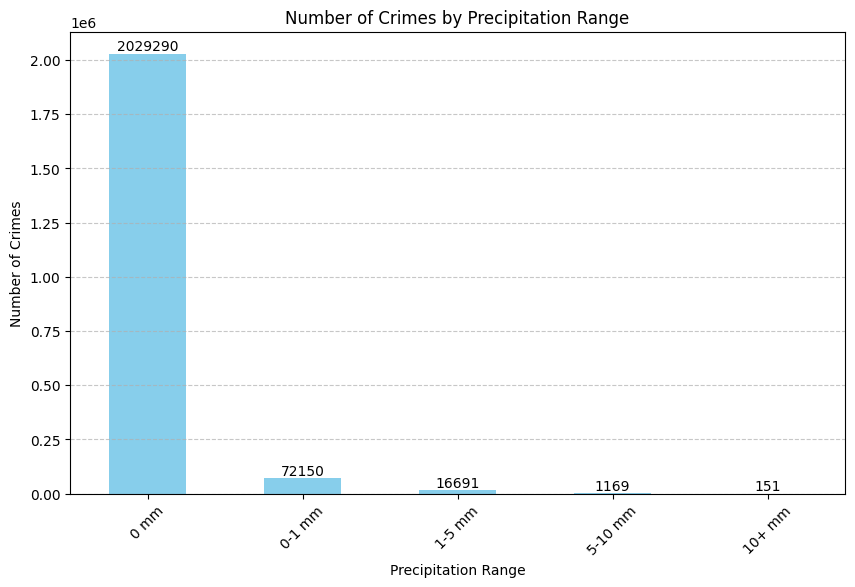

In [23]:
# Define precipitation bins and labels
precip_bins = [-0.1, 0, 1, 5, 10, 20]  # -0.1 ensures 0 is included
precip_labels = ['0 mm', '0-1 mm', '1-5 mm', '5-10 mm', '10+ mm']

# Create a new column for precipitation range
data['PRECIP_RANGE'] = pd.cut(data['PERCIPITATION'], bins=precip_bins, labels=precip_labels, include_lowest=True)

# Count crimes in each precipitation range
precip_counts = data['PRECIP_RANGE'].value_counts().sort_index()

# Drop the temporary column
data.drop(columns=['PRECIP_RANGE'], inplace=True)

# Plot
plt.figure(figsize=(10,6))
bars = precip_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Crimes by Precipitation Range')
plt.xlabel('Precipitation Range')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add numbers on top of each bar
for i, count in enumerate(precip_counts):
    plt.text(i, count + 500, str(count), ha='center', va='bottom', fontsize=10)  # +500 for spacing

plt.show()

In [24]:
print(data['WIND SPEED'].describe())

count    2.119451e+06
mean     7.781334e+00
std      4.683588e+00
min      0.000000e+00
25%      4.300000e+00
50%      6.900000e+00
75%      1.050000e+01
max      7.820000e+01
Name: WIND SPEED, dtype: float64


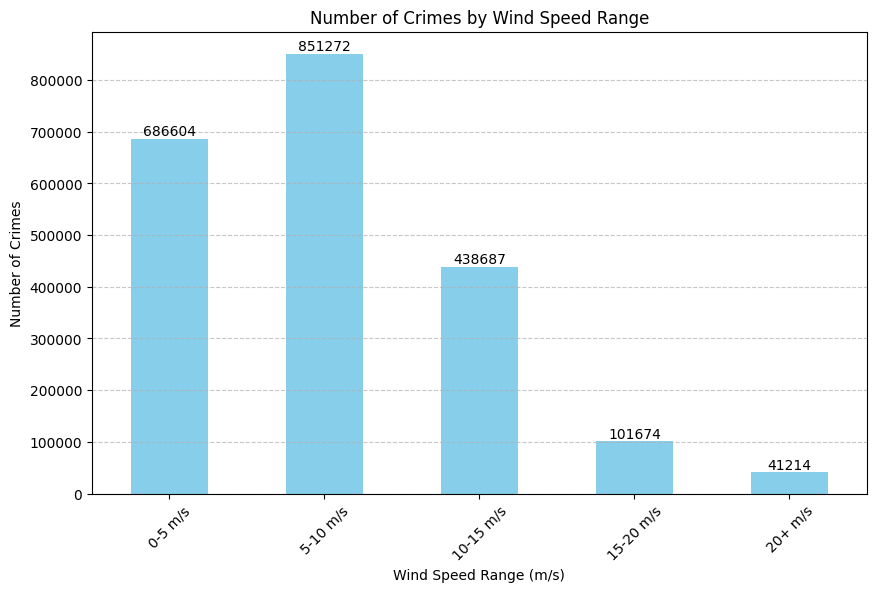

In [25]:
# Define wind speed bins (m/s) and labels
wind_bins = [0, 5, 10, 15, 20, 80]  # Upper bound 80 to include max
wind_labels = ['0-5 m/s', '5-10 m/s', '10-15 m/s', '15-20 m/s', '20+ m/s']

# Create a new column for wind speed range
data['WIND_RANGE'] = pd.cut(data['WIND SPEED'], bins=wind_bins, labels=wind_labels, include_lowest=True)

# Count crimes in each wind range
wind_counts = data['WIND_RANGE'].value_counts().sort_index()

# Drop the temporary column
data.drop(columns=['WIND_RANGE'], inplace=True)

# Plot
plt.figure(figsize=(10,6))
bars = wind_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Crimes by Wind Speed Range')
plt.xlabel('Wind Speed Range (m/s)')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add numbers on top of each bar
for i, count in enumerate(wind_counts):
    plt.text(i, count + 500, str(count), ha='center', va='bottom', fontsize=10)

plt.show()

In [26]:
print(data['RAIN'].describe())

count    2.119451e+06
mean     3.244199e-02
std      2.898924e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.650000e+01
Name: RAIN, dtype: float64


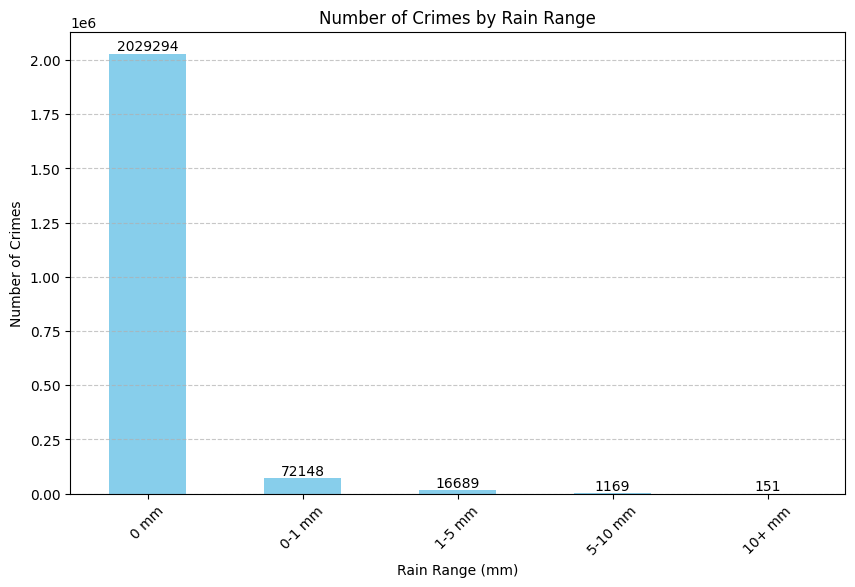

In [27]:
# Define rain bins and labels
rain_bins = [-0.1, 0, 1, 5, 10, 20]  # -0.1 ensures 0 is included
rain_labels = ['0 mm', '0-1 mm', '1-5 mm', '5-10 mm', '10+ mm']

# Create a new column for rain range
data['RAIN_RANGE'] = pd.cut(data['RAIN'], bins=rain_bins, labels=rain_labels, include_lowest=True)

# Count crimes in each rain range
rain_counts = data['RAIN_RANGE'].value_counts().sort_index()

# Drop the temporary column
data.drop(columns=['RAIN_RANGE'], inplace=True)

# Plot
plt.figure(figsize=(10,6))
bars = rain_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Crimes by Rain Range')
plt.xlabel('Rain Range (mm)')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add numbers on top of each bar
for i, count in enumerate(rain_counts):
    plt.text(i, count + 500, str(count), ha='center', va='bottom', fontsize=10)

plt.show()

In [28]:
print(data['SNOWFALL'].describe())

count    2.119451e+06
mean     2.212837e-06
std      4.926934e-04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.400000e-01
Name: SNOWFALL, dtype: float64


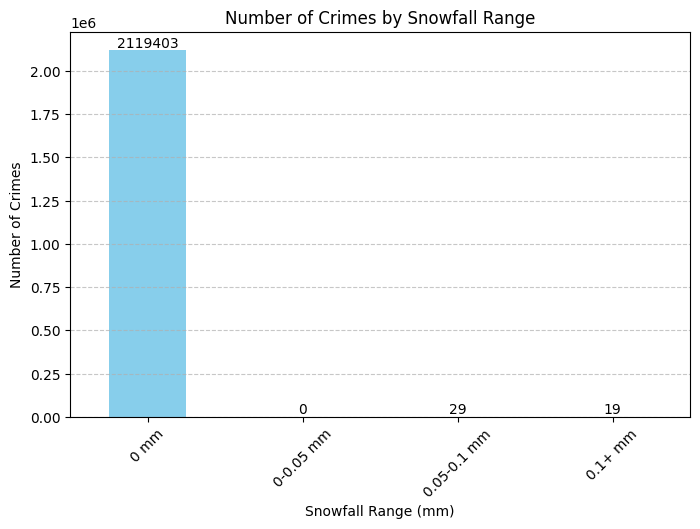

In [29]:
# Define snowfall bins (mm)
snow_bins = [-0.01, 0, 0.05, 0.1, 1]  # -0.01 ensures exact 0 is included
snow_labels = ['0 mm', '0-0.05 mm', '0.05-0.1 mm', '0.1+ mm']

# Create a new column for snowfall range
data['SNOW_RANGE'] = pd.cut(data['SNOWFALL'], bins=snow_bins, labels=snow_labels, include_lowest=True)

# Count crimes in each snowfall range
snow_counts = data['SNOW_RANGE'].value_counts().sort_index()

# Drop the temporary column
data.drop(columns=['SNOW_RANGE'], inplace=True)

# Plot
plt.figure(figsize=(8,5))
bars = snow_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Crimes by Snowfall Range')
plt.xlabel('Snowfall Range (mm)')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add numbers on top of each bar
for i, count in enumerate(snow_counts):
    plt.text(i, count + 10, str(count), ha='center', va='bottom', fontsize=10)  # +10 for spacing

plt.show()